# Instructor Effectiveness Modeling

This project analyzes instructor performance using learner outcomes, engagement, and feedback data. 
The goal is to define instructor effectiveness and build a machine learning model to predict effectiveness tiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("project.csv")  
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [4]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

### Missing Values Analysis

There are no missing values in the dataset. 
This ensures data quality and allows us to proceed directly with analysis and modeling without imputation.

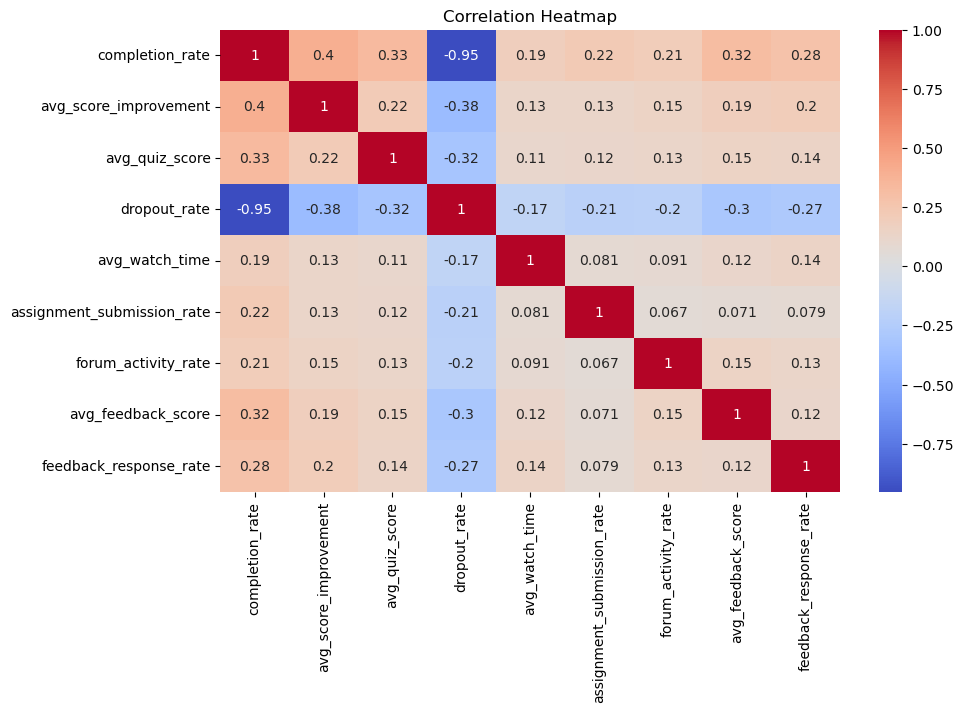

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

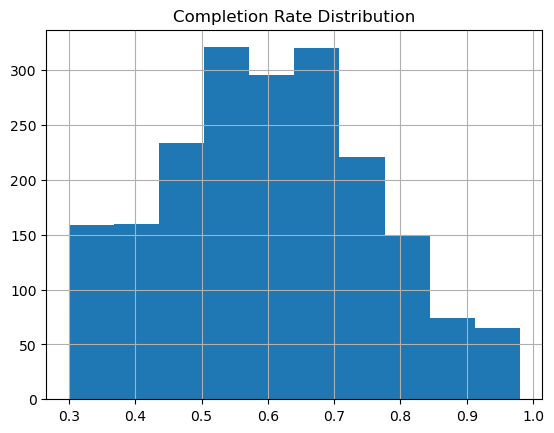

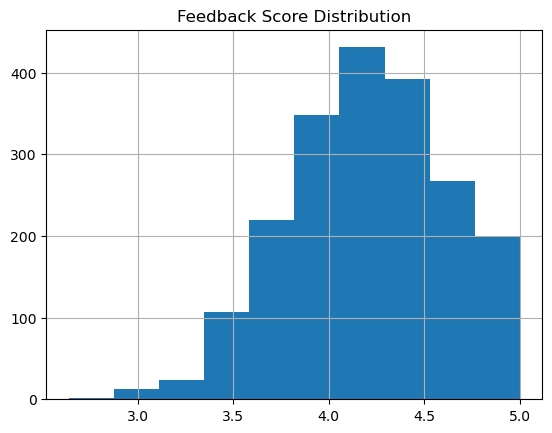

In [6]:
df['completion_rate'].hist()
plt.title("Completion Rate Distribution")
plt.show()

df['avg_feedback_score'].hist()
plt.title("Feedback Score Distribution")
plt.show()

### Observations

- Completion rate is positively correlated with feedback score.
- Dropout rate shows a negative relationship with completion.
- Engagement features also show moderate correlation with outcomes.
- Most batches show moderate to high performance levels.

In [7]:
# Normalize feedback (1–5 scale → 0–1)
df['feedback_normalized'] = df['avg_feedback_score'] / 5

# Engagement score (combined metric)
df['engagement_score'] = (
    df['avg_watch_time'] +
    df['assignment_submission_rate'] +
    df['forum_activity_rate']
) / 3

In [8]:
df['effectiveness_score'] = (
    0.30 * df['completion_rate'] +
    0.20 * df['avg_score_improvement'] +
    0.20 * df['feedback_normalized'] +
    0.15 * df['engagement_score'] -
    0.15 * df['dropout_rate']
)

### Effectiveness Definition

The effectiveness score combines:

- Learning outcomes (completion rate, score improvement)
- Student satisfaction (normalized feedback)
- Engagement (combined engagement score)
- Retention (dropout rate as penalty)

Feature normalization and aggregation improve consistency and interpretability.

This approach ensures a balance between performance, engagement, and satisfaction, making the metric more realistic for real-world EdTech scenarios.

In [9]:
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [10]:
instructor_df = df.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'dropout_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'engagement_score': 'mean',
    'effectiveness_score': 'mean'
}).reset_index()

In [11]:
batch_count = df.groupby('instructor_id').size().reset_index(name='num_batches')
instructor_df = instructor_df.merge(batch_count, on='instructor_id')

In [12]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [13]:
X = instructor_df.drop(['instructor_id', 'effectiveness_tier'], axis=1)
y = instructor_df['effectiveness_tier']

In [14]:
y.value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

        High       1.00      0.67      0.80         9
         Low       1.00      0.75      0.86         8
      Medium       0.58      1.00      0.74         7

    accuracy                           0.79        24
   macro avg       0.86      0.81      0.80        24
weighted avg       0.88      0.79      0.80        24



In [18]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         7

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



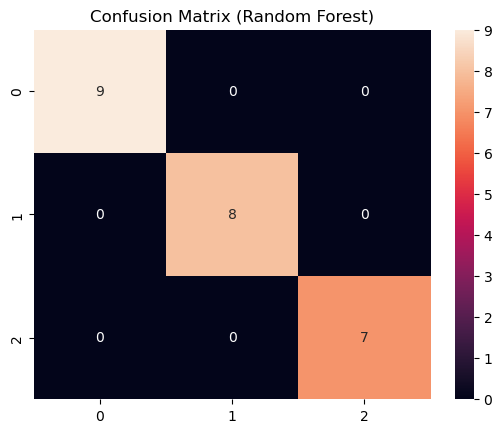

In [19]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.show()

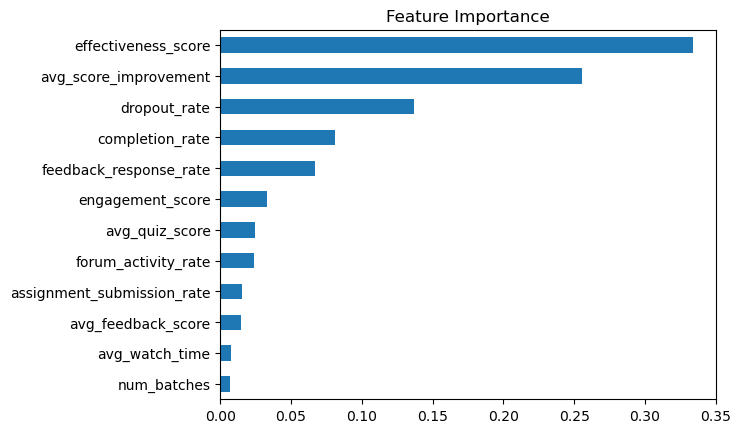

In [20]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

### Model Comparison

- Logistic Regression provides interpretability.
- Random Forest captures complex relationships.

Random Forest performs better, indicating non-linear interactions between features.

### Q1: Important Features
Completion rate, engagement score, and feedback are most influential as they capture learning success and satisfaction.

### Q2: Misleading Variables
Engagement metrics like watch time may not always reflect actual learning effectiveness.

### Q3: Model Limitations
The model lacks context such as course difficulty, student background, and teaching style. 
There may also be bias if certain instructors teach easier or harder courses.

### Q4: Additional Data Needed
Course difficulty, student demographics, and instructor experience would improve predictions.

### Q5: Should Model Be Used?
The model can assist decision-making but should not be the sole evaluation tool due to potential bias and missing context.